# 04 - Latent Autoencoder + Latent Propagator (t -> t+20)

Training plan:

1. Train autoencoder: `graph -> latent (CVs) -> reconstructed positions`.
2. Freeze encoder/decoder, train latent propagator MLP on `z_t -> z_{t+20}`.
3. Validate by predicting frame `t+20` from frame `t=0` and measuring p-ratio change quality.


In [6]:
import sys
from pathlib import Path

SRC_DIR = (Path.cwd().resolve() / '..' / 'src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

for name in list(sys.modules.keys()):
    if name == 'course_project' or name.startswith('course_project.'):
        del sys.modules[name]

import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch_geometric.data import Data

from graph_utils import calc_p_ratio_box, draw_graph_comparison, pyg_to_networkx

from course_project.config import ExperimentConfig
from course_project.data import load_dataset
from course_project.graph import build_graph
from course_project.models import create_model
from course_project.utils import resolve_device


In [7]:
seed = 56345
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

cfg = ExperimentConfig(
    run_name='latent_autoencoder_t20',
    model_type='latent_space',
    train_dataset='../data/2340_dePablo_networks_OOL_undirected_train10.pt',
    val_dataset='../data/2340_dePablo_networks_OOL_undirected_val100.pt',
    output_root='../results',
    device='cuda',
    pos_dim=2,
    history=1,
    node_features='positions',
    limit=60,
    hidden_size=128,
    n_layers=2,
    model_extras={
        'num_mlp': 3,
        'K1': 350,
        'CV': 2,
        'transformer_layers': 1,
        'transformer_heads': 1,
        'transformer_dropout': 0.0,
        'edge_aggr': 'mean',
        'use_local_skip': False,
    },
    learning_rate=1e-4,
    learning_rate_decay=1.0,
    weight_decay=0.0,
    epochs=1,
    val_every=1,
    rollout_every=0,
    cv_eval_every=0,
    rollout_steps=20,
    train_rollout_steps=1,
    seed=seed,
    verbose=True,
)

horizon = 20
stage1_epochs = 10
stage1_lr = 5e-4
stage2_epochs = 10
stage2_lr = 2e-4
stage2_pos_weight = 1.0


In [8]:
def eval_ae_loss(model, sims, cfg, device: str) -> float:
    model.eval()
    losses = []
    with torch.no_grad():
        for sim in sims:
            sim_len = min(len(sim), cfg.limit)
            for t in range(sim_len):
                g = build_graph([sim[t].to(device)], node_features=cfg.node_features).to(device)
                pred_pos, _z = model.autoencode_positions(g, is_training=False)
                target_pos = g.x[:, :cfg.pos_dim]
                losses.append(float(F.mse_loss(pred_pos, target_pos).item()))
    return float(np.mean(losses)) if losses else float('nan')


def eval_prop_loss(model, sims, cfg, device: str, horizon: int, pos_w: float) -> float:
    model.eval()
    losses = []
    with torch.no_grad():
        for sim in sims:
            sim_len = min(len(sim), cfg.limit)
            for t in range(sim_len - horizon):
                g_t = build_graph([sim[t].to(device)], node_features=cfg.node_features).to(device)
                g_h = build_graph([sim[t + horizon].to(device)], node_features=cfg.node_features).to(device)

                z_t = model.encode_latent(g_t, is_training=False)
                z_h = model.encode_latent(g_h, is_training=False)
                z_pred = model.propagate_latent(z_t)
                pos_pred = model.decode_positions_from_latent(g_t, z_pred, is_training=False)
                pos_target = g_h.x[:, :cfg.pos_dim]

                loss = F.mse_loss(z_pred, z_h) + pos_w * F.mse_loss(pos_pred, pos_target)
                losses.append(float(loss.item()))
    return float(np.mean(losses)) if losses else float('nan')


def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return float(1.0 - ss_res / ss_tot)


def pearson_r(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.corrcoef(y_true, y_pred)[0, 1])


In [9]:
device = resolve_device(cfg.device)
print('device:', device)

train_data = load_dataset(cfg.train_dataset)
val_data = load_dataset(cfg.val_dataset)

init_graph = build_graph([train_data[0][0].to(device)], node_features=cfg.node_features).to(device)
model = create_model(
    model_type=cfg.model_type,
    init_graph=init_graph,
    pos_dim=cfg.pos_dim,
    hidden_size=cfg.hidden_size,
    n_layers=cfg.n_layers,
    extras=cfg.model_extras,
).to(device)

print(type(model).__name__)


device: cuda
Model


In [10]:
# Stage 1: autoencoder training
for p in model.parameters():
    p.requires_grad = True
for p in model.core.latent_dynamics.parameters():
    p.requires_grad = False
model.core.latent_dynamics.delta_scale = 0.0

opt1 = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=stage1_lr)

ae_train_losses = []
ae_val_losses = []

for epoch in range(stage1_epochs):
    model.train()

    losses = []
    for sim in train_data:
        sim_len = min(len(sim), cfg.limit)
        for t in range(sim_len):
            g = build_graph([sim[t].to(device)], node_features=cfg.node_features).to(device)
            pred_pos, _z = model.autoencode_positions(g, is_training=True)
            target_pos = g.x[:, :cfg.pos_dim]
            loss = F.mse_loss(pred_pos, target_pos)

            opt1.zero_grad()
            loss.backward()
            opt1.step()
            losses.append(float(loss.detach().cpu().item()))

    tr = float(np.mean(losses)) if losses else float('nan')
    va = eval_ae_loss(model, val_data, cfg, device)
    ae_train_losses.append(tr)
    ae_val_losses.append(va)
    print(f'[AE {epoch + 1:03d}/{stage1_epochs}] tr={tr:.6g} va={va:.6g}')


[AE 001/10] tr=0.976315 va=1.00395
[AE 002/10] tr=0.944091 va=1.00404
[AE 003/10] tr=0.940204 va=1.0039
[AE 004/10] tr=0.938724 va=1.00391
[AE 005/10] tr=0.93786 va=1.00392
[AE 006/10] tr=0.93491 va=1.00387
[AE 007/10] tr=0.935116 va=1.00424
[AE 008/10] tr=0.935098 va=1.00404
[AE 009/10] tr=0.935074 va=1.00344
[AE 010/10] tr=0.935193 va=1.00352


In [ ]:
# Quick AE visual check: one GT graph vs reconstructed graph
model.eval()
sim_i = 0
t_i = 0

g_gt = build_graph([val_data[sim_i][t_i].to(device)], node_features=cfg.node_features).to(device)
pred_pos, _ = model.autoencode_positions(g_gt, is_training=False)

g_pred = Data(
    x=pred_pos.detach().cpu(),
    edge_index=g_gt.edge_index.detach().cpu(),
    edge_attr=g_gt.edge_attr.detach().cpu() if g_gt.edge_attr is not None else None,
    box=g_gt.box if hasattr(g_gt, 'box') else None,
    t=g_gt.t if hasattr(g_gt, 't') else None,
    dtype=g_gt.x.dtype,
)

G_gt = pyg_to_networkx(g_gt.detach().cpu(), pos_slice=(0, cfg.pos_dim))
G_pred = pyg_to_networkx(g_pred, pos_slice=(0, cfg.pos_dim))
draw_graph_comparison(G_gt, G_pred, show_displacement=True)


In [11]:
# Stage 2: latent propagator training for direct t -> t+20
for p in model.parameters():
    p.requires_grad = False
for p in model.core.latent_dynamics.parameters():
    p.requires_grad = True
model.core.latent_dynamics.delta_scale = 0.1

opt2 = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=stage2_lr)

prop_train_losses = []
prop_val_losses = []

for epoch in range(stage2_epochs):
    model.train()
    losses = []

    for sim in train_data:
        sim_len = min(len(sim), cfg.limit)
        for t in range(sim_len - horizon):
            g_t = build_graph([sim[t].to(device)], node_features=cfg.node_features).to(device)
            g_h = build_graph([sim[t + horizon].to(device)], node_features=cfg.node_features).to(device)

            with torch.no_grad():
                z_t = model.encode_latent(g_t, is_training=False)
                z_h = model.encode_latent(g_h, is_training=False)

            z_pred = model.propagate_latent(z_t)
            pos_pred = model.decode_positions_from_latent(g_t, z_pred, is_training=False)
            pos_target = g_h.x[:, :cfg.pos_dim]

            loss = F.mse_loss(z_pred, z_h) + stage2_pos_weight * F.mse_loss(pos_pred, pos_target)

            opt2.zero_grad()
            loss.backward()
            opt2.step()
            losses.append(float(loss.detach().cpu().item()))

    tr = float(np.mean(losses)) if losses else float('nan')
    va = eval_prop_loss(model, val_data, cfg, device, horizon=horizon, pos_w=stage2_pos_weight)
    prop_train_losses.append(tr)
    prop_val_losses.append(va)
    print(f'[PROP {epoch + 1:03d}/{stage2_epochs}] tr={tr:.6g} va={va:.6g}')


[PROP 001/10] tr=0.936104 va=1.00283
[PROP 002/10] tr=0.936104 va=1.00283
[PROP 003/10] tr=0.936104 va=1.00283
[PROP 004/10] tr=0.936104 va=1.00283
[PROP 005/10] tr=0.936104 va=1.00283
[PROP 006/10] tr=0.936104 va=1.00283
[PROP 007/10] tr=0.936104 va=1.00283
[PROP 008/10] tr=0.936104 va=1.00283
[PROP 009/10] tr=0.936104 va=1.00283
[PROP 010/10] tr=0.936104 va=1.00283


In [12]:
# Validation: use frame 0 -> predict frame +20, score p-ratio change
model.eval()

pred_delta_pr = []
target_delta_pr = []
pos_mse_vals = []

with torch.no_grad():
    for sim in val_data:
        if len(sim) <= horizon:
            continue

        g0 = build_graph([sim[0].to(device)], node_features=cfg.node_features).to(device)
        pred_pos, z0, z20 = model.predict_tplus_positions(g0, is_training=False)
        target_pos = sim[horizon].to(device).x[:, :cfg.pos_dim]
        pos_mse_vals.append(float(F.mse_loss(pred_pos, target_pos).item()))

        pred_graph = Data(
            x=pred_pos.detach().cpu(),
            edge_index=sim[0].edge_index,
            edge_attr=sim[0].edge_attr,
            box=sim[0].box if hasattr(sim[0], 'box') else None,
            t=sim[horizon].t if hasattr(sim[horizon], 't') else None,
            dtype=sim[0].x.dtype,
        )

        base_pr = float(calc_p_ratio_box(sim, 0))
        target_pr = float(calc_p_ratio_box(sim, horizon))
        pred_pr = float(calc_p_ratio_box([sim[0], pred_graph], -1))

        pred_delta_pr.append(pred_pr - base_pr)
        target_delta_pr.append(target_pr - base_pr)

print('Validation (frame0 -> frame+20):')
print('  delta p-ratio R2      =', r2_score(target_delta_pr, pred_delta_pr))
print('  delta p-ratio Pearson =', pearson_r(target_delta_pr, pred_delta_pr))
print('  position MSE          =', float(np.mean(pos_mse_vals)) if pos_mse_vals else float('nan'))
print('  used sims             =', len(pos_mse_vals))

# Scatter: predicted vs GT delta p-ratio (frame 0 -> frame + horizon)
x = np.asarray(target_delta_pr, dtype=float)
y = np.asarray(pred_delta_pr, dtype=float)

fig, ax = plt.subplots(figsize=(5.6, 5.2))
ax.scatter(x, y, s=26, alpha=0.8)
lo = float(min(x.min(), y.min()))
hi = float(max(x.max(), y.max()))
pad = 0.05 * (hi - lo + 1e-12)
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--', linewidth=1.1)
ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)
ax.set_xlabel(f'GT Δp-ratio (0 -> {horizon})')
ax.set_ylabel(f'Predicted Δp-ratio (0 -> {horizon})')
ax.set_title('Validation Δp-ratio Scatter')
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


Validation (frame0 -> frame+20):
  delta p-ratio R2      = -0.040491397661343465
  delta p-ratio Pearson = nan
  position MSE          = 20.02931597709656
  used sims             = 100


/home/alexz/miniconda3/envs/modular-network-simulator/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/alexz/miniconda3/envs/modular-network-simulator/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


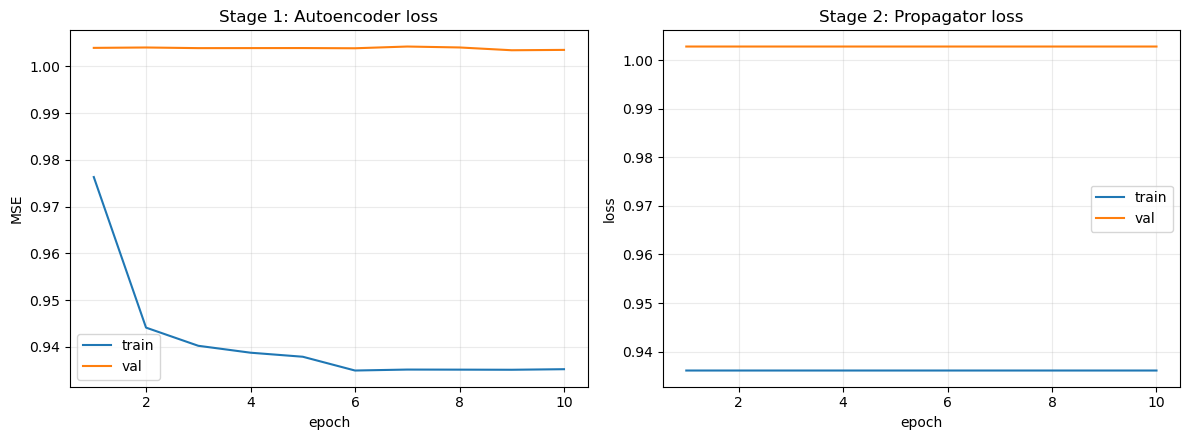

In [13]:
# Loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(np.arange(1, len(ae_train_losses) + 1), ae_train_losses, label='train')
axes[0].plot(np.arange(1, len(ae_val_losses) + 1), ae_val_losses, label='val')
axes[0].set_title('Stage 1: Autoencoder loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('MSE')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(np.arange(1, len(prop_train_losses) + 1), prop_train_losses, label='train')
axes[1].plot(np.arange(1, len(prop_val_losses) + 1), prop_val_losses, label='val')
axes[1].set_title('Stage 2: Propagator loss')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('loss')
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
plt.show()
